In [1]:
#Day 12 | 17 May 2026 | Maryam Naveen
#Topic: Matplotlib + Seaborn — Advanced Visualisations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv(r'C:\Users\marya\OneDrive\Documents\GitHub\data-analytics-portfolio\day-07-sql-project\UK_Accident.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.month
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour

print(f"Dataset loaded: {df.shape}")
print("Ready for advanced visualisations!")

Dataset loaded: (1504150, 35)
Ready for advanced visualisations!


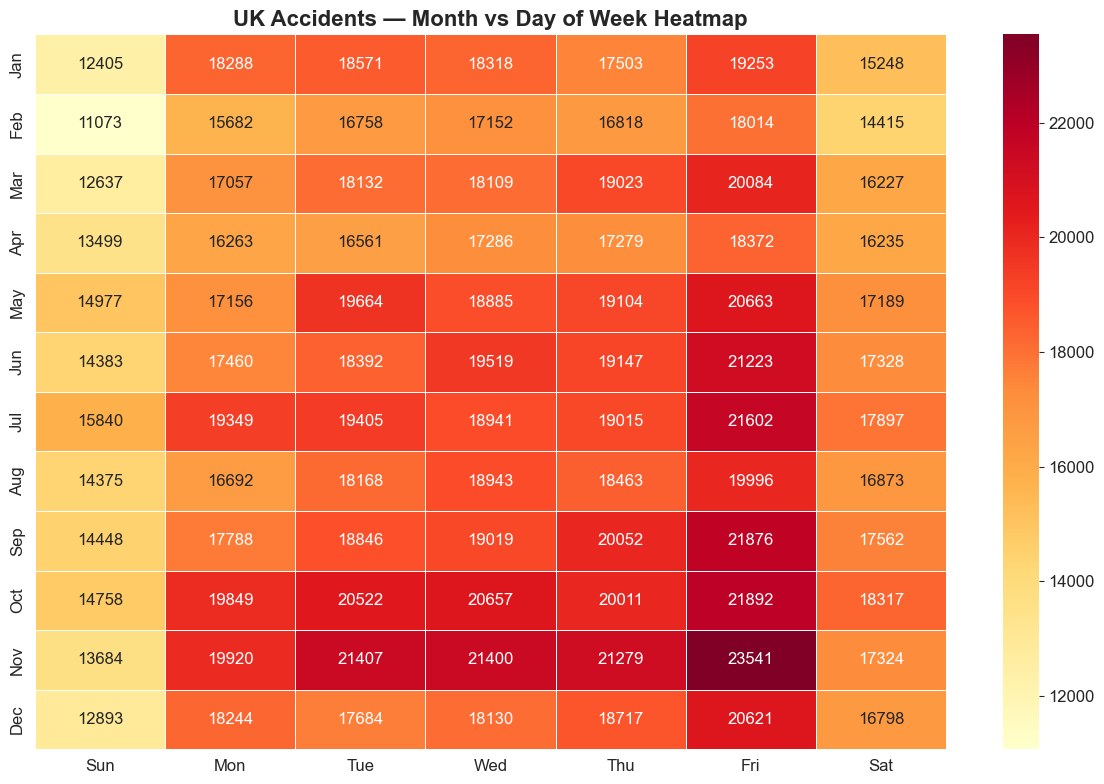

Chart 10 saved!


In [2]:
#Chart 1: Heatmap — accidents by month and day of week
month_day = df.groupby(['Month', 'Day_of_Week']).size().unstack()
month_day.columns = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
month_day.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 8))
sns.heatmap(month_day, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5)
plt.title('UK Accidents — Month vs Day of Week Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart10_heatmap.png', dpi=150)
plt.show()
print("Chart 10 saved!")

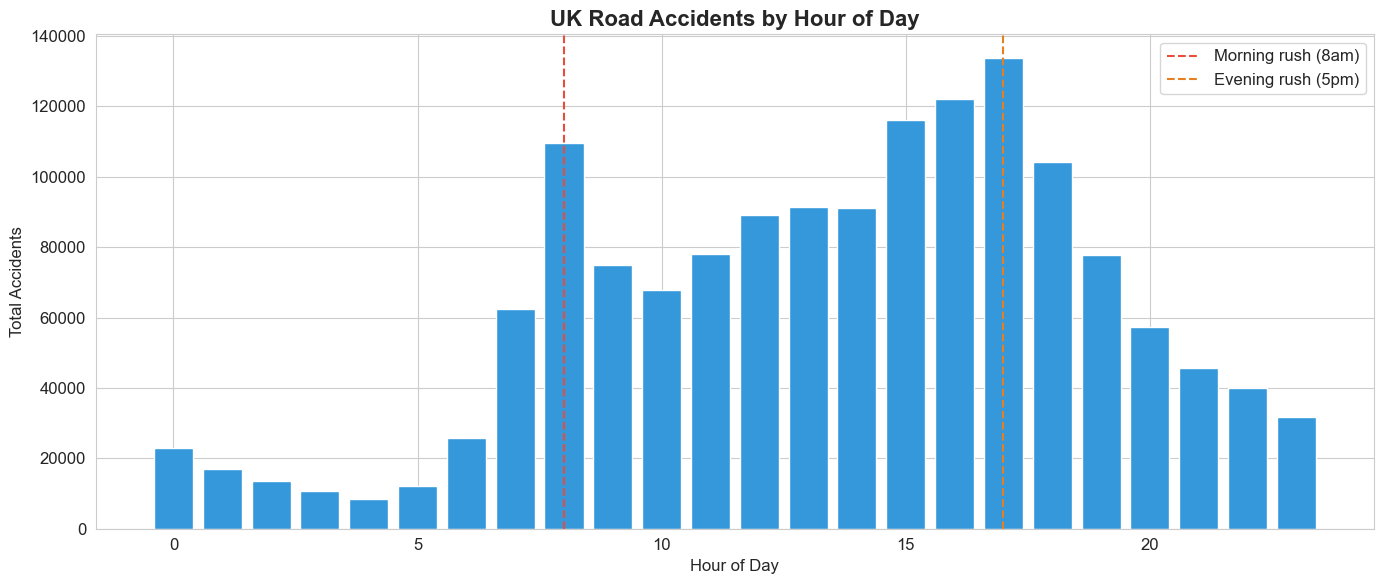

Chart 11 saved!


In [3]:
#Chart 2: Accidents by hour of day
hourly = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
plt.bar(hourly.index, hourly.values, color='#3498DB', edgecolor='white')
plt.axvline(x=8, color='#E74C3C', linestyle='--', label='Morning rush (8am)')
plt.axvline(x=17, color='#E67E22', linestyle='--', label='Evening rush (5pm)')
plt.title('UK Road Accidents by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Total Accidents')
plt.legend()
plt.tight_layout()
plt.savefig('chart11_hourly.png', dpi=150)
plt.show()
print("Chart 11 saved!")

C:\Users\marya\AppData\Local\Temp\ipykernel_4760\1943394862.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity_Label', y='Number_of_Casualties',


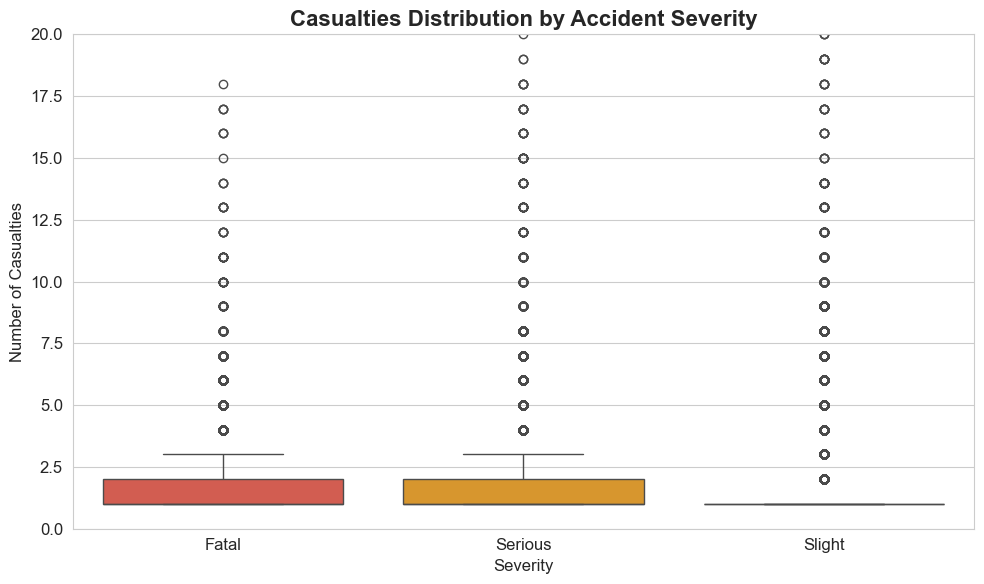

Chart 12 saved!


In [4]:
#Chart 3: Box plot — casualties by severity
plt.figure(figsize=(10, 6))
severity_labels = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
df['Severity_Label'] = df['Accident_Severity'].map(severity_labels)

sns.boxplot(data=df, x='Severity_Label', y='Number_of_Casualties',
            palette=['#E74C3C', '#F39C12', '#2ECC71'],
            order=['Fatal', 'Serious', 'Slight'])
plt.title('Casualties Distribution by Accident Severity', fontsize=16, fontweight='bold')
plt.xlabel('Severity')
plt.ylabel('Number of Casualties')
plt.ylim(0, 20)
plt.tight_layout()
plt.savefig('chart12_boxplot.png', dpi=150)
plt.show()
print("Chart 12 saved!")

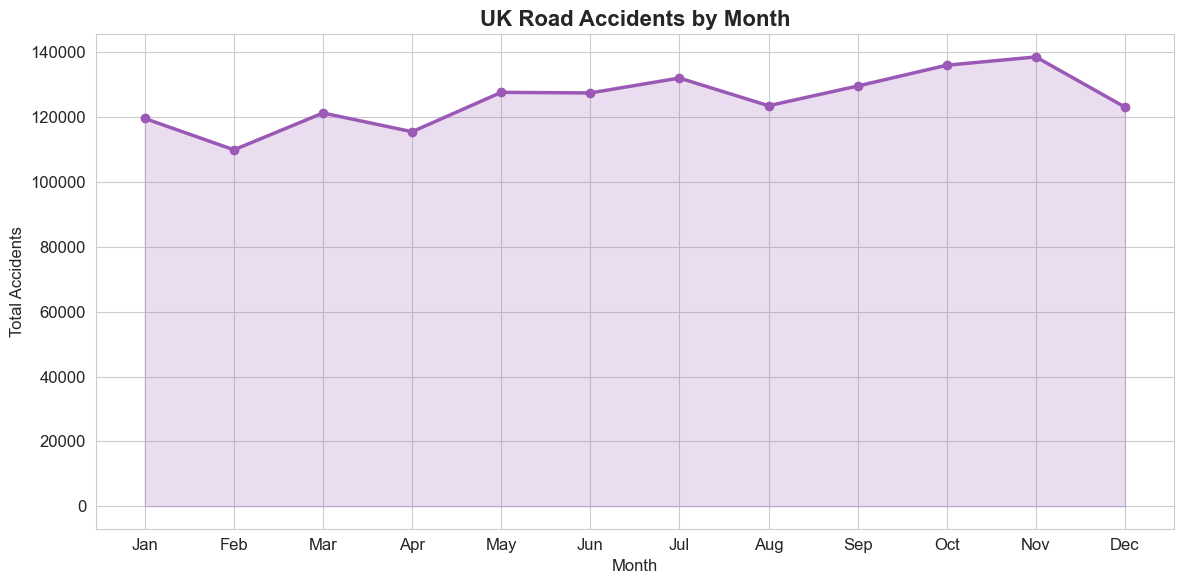

Chart 13 saved!


In [5]:
#Chart 4: Monthly accident trend
monthly = df.groupby('Month').size()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
plt.plot(month_names, monthly.values, marker='o', color='#9B59B6', linewidth=2.5)
plt.fill_between(range(12), monthly.values, alpha=0.2, color='#9B59B6')
plt.xticks(range(12), month_names)
plt.title('UK Road Accidents by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Accidents')
plt.tight_layout()
plt.savefig('chart13_monthly.png', dpi=150)
plt.show()
print("Chart 13 saved!")

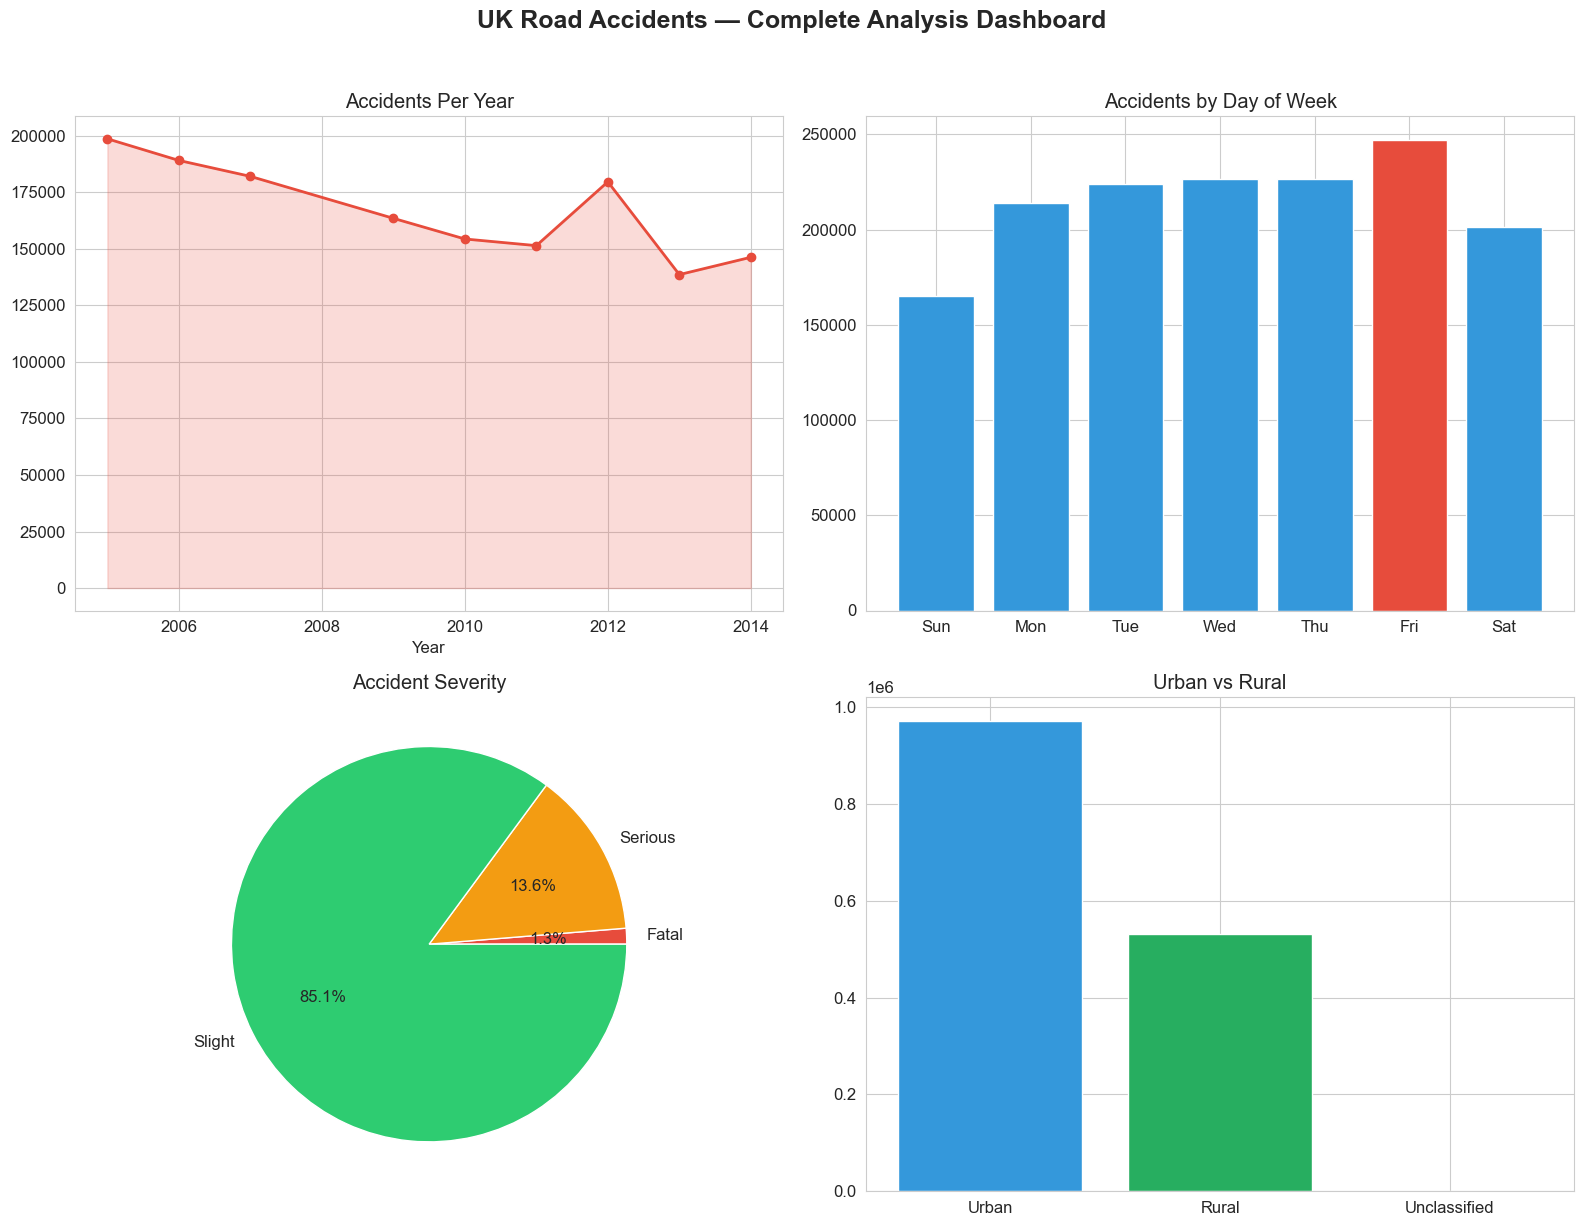

Chart 14 — Dashboard saved!


In [6]:
#Chart 5: Multi-panel figure — the full story
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('UK Road Accidents — Complete Analysis Dashboard',
             fontsize=18, fontweight='bold', y=1.02)

#Panel 1: yearly trend
yearly = df.groupby('Year').size()
axes[0,0].plot(yearly.index, yearly.values, marker='o', color='#E74C3C', linewidth=2)
axes[0,0].fill_between(yearly.index, yearly.values, alpha=0.2, color='#E74C3C')
axes[0,0].set_title('Accidents Per Year')
axes[0,0].set_xlabel('Year')

#Panel 2: day of week
days = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
day_counts = df['Day_of_Week'].value_counts().sort_index()
colors = ['#3498DB']*5 + ['#E74C3C'] + ['#3498DB']
axes[0,1].bar(days, day_counts.values, color=colors)
axes[0,1].set_title('Accidents by Day of Week')

#Panel 3: severity pie
severity_counts = df['Accident_Severity'].value_counts().sort_index()
axes[1,0].pie(severity_counts.values, labels=['Fatal','Serious','Slight'],
              autopct='%1.1f%%', colors=['#E74C3C','#F39C12','#2ECC71'])
axes[1,0].set_title('Accident Severity')

#Panel 4: urban vs rural
ur = df['Urban_or_Rural_Area'].value_counts().sort_index()
axes[1,1].bar(['Urban','Rural','Unclassified'], ur.values,
              color=['#3498DB','#27AE60','#95A5A6'])
axes[1,1].set_title('Urban vs Rural')

plt.tight_layout()
plt.savefig('chart14_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 14 — Dashboard saved!")